<a href="https://colab.research.google.com/github/IshitaSharma009/ML/blob/Feature-Engineering/numerical_data_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
!kaggle datasets download shuofxz/titanic-machine-learning-from-disaster

Dataset URL: https://www.kaggle.com/datasets/shuofxz/titanic-machine-learning-from-disaster
License(s): DbCL-1.0
titanic-machine-learning-from-disaster.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
import zipfile
zip_ref=zipfile.ZipFile('titanic-machine-learning-from-disaster.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [86]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer

In [87]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [88]:
df.shape

(891, 3)

In [89]:
df.dropna(inplace=True)

In [90]:

df.shape

(714, 3)

In [91]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [92]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [93]:
x_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [94]:
x_train.isnull().sum()

,0
Age,0
Fare,0


In [95]:
clf=DecisionTreeClassifier()


In [96]:
clf.fit(x_train,y_train)
y_pred= clf.predict(x_test)

In [97]:
accuracy_score(y_pred,y_test)

0.6223776223776224

In [98]:
cross_val_score(clf,x,y, scoring='accuracy',cv=10)

array([0.61111111, 0.58333333, 0.63888889, 0.65277778, 0.57746479,
       0.71830986, 0.74647887, 0.6056338 , 0.56338028, 0.6056338 ])

In [99]:
np.mean(cross_val_score(clf,x,y, scoring='accuracy',cv=10))

np.float64(0.6358959311424099)

In [100]:
k_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='kmeans')

In [125]:

def bin_discretizer(n_bins,encode,strategy):
    trf =ColumnTransformer([
    ('k_age',KBinsDiscretizer(n_bins=n_bins,encode=encode,strategy=strategy),['Age','Fare'])

    ],remainder='passthrough')

    x_new=trf.fit_transform(x)
    x__new =pd.DataFrame(x_new)

    clf=DecisionTreeClassifier()
    print(np.mean(cross_val_score(clf,x_new,y,scoring='accuracy',cv=10)))


    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title('before age')

    plt.subplot(122)
    plt.hist(x__new[0],color='red')
    plt.title('after age')


    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title('before fare')

    plt.subplot(122)
    plt.hist(x__new[1],color='red')
    plt.title('after fare')




0.682140062597809


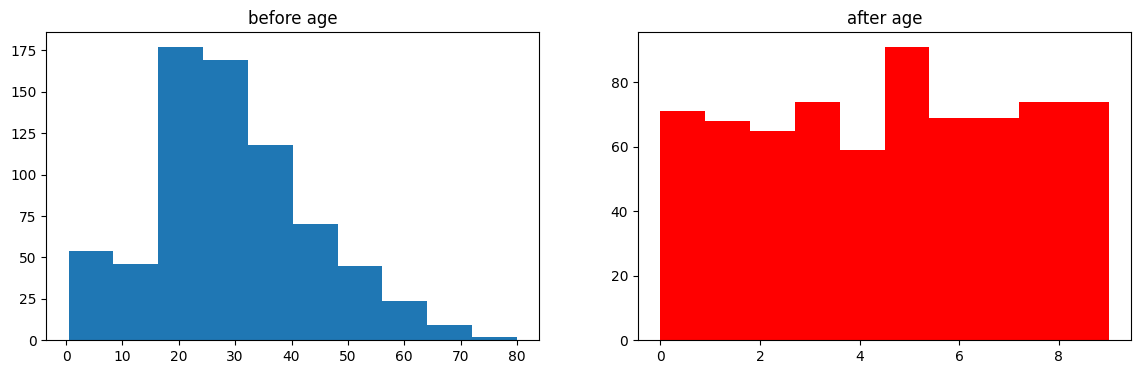

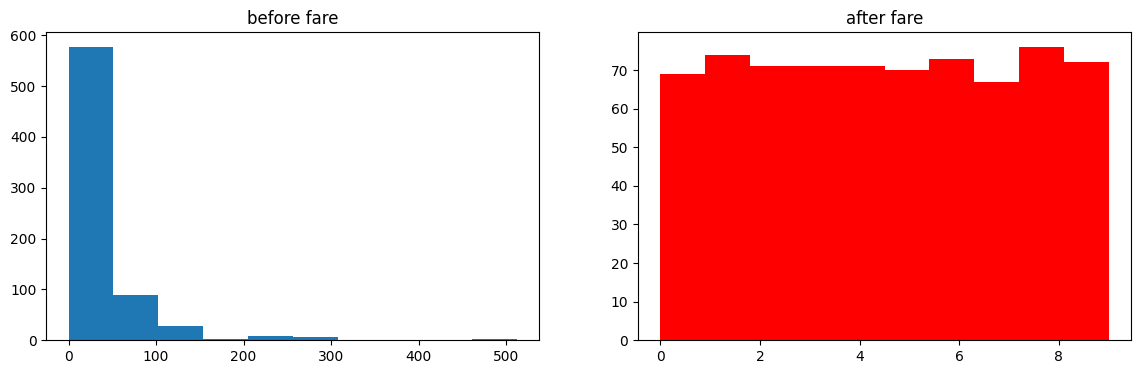

In [126]:
bin_discretizer(10,'ordinal','quantile')

0.6864632237871675


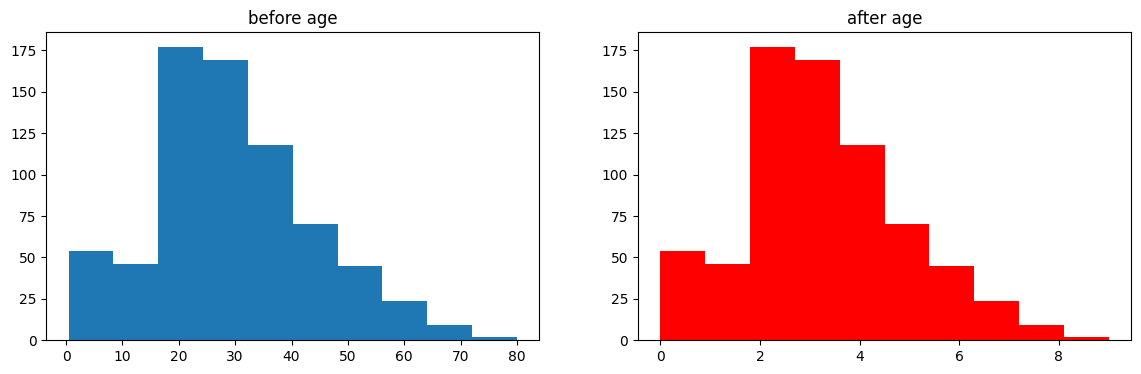

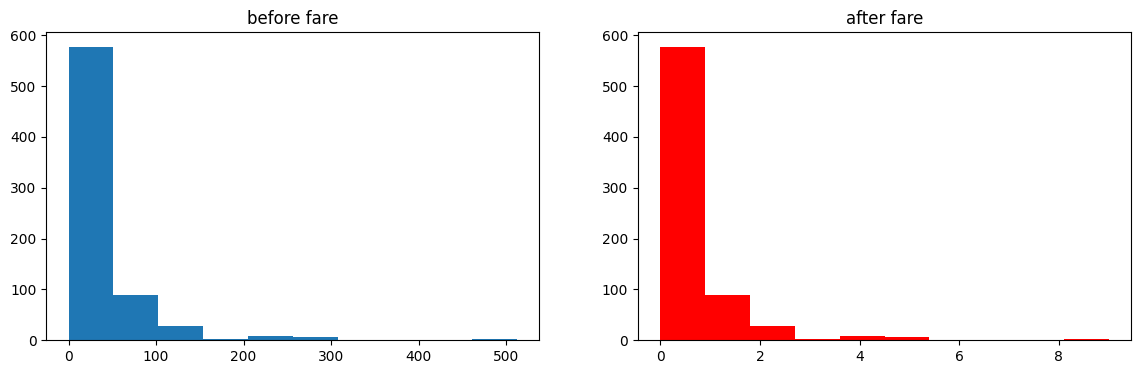

In [127]:
bin_discretizer(10,'ordinal','uniform')

0.6723982785602504


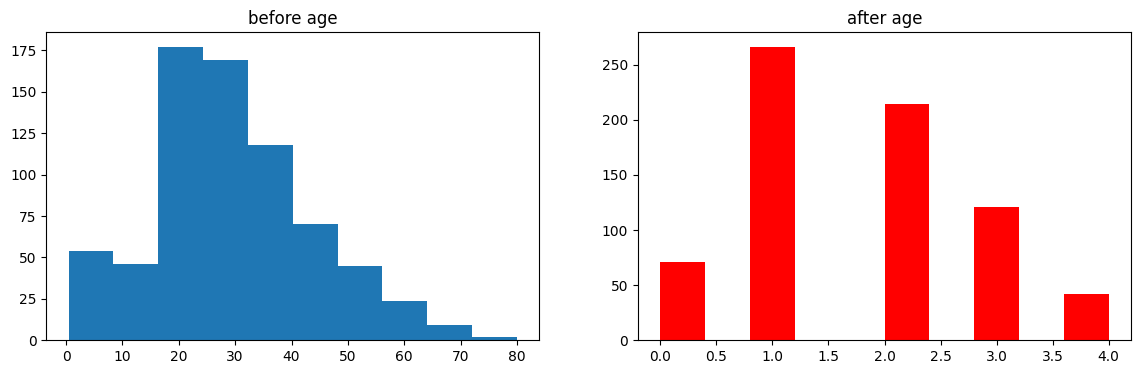

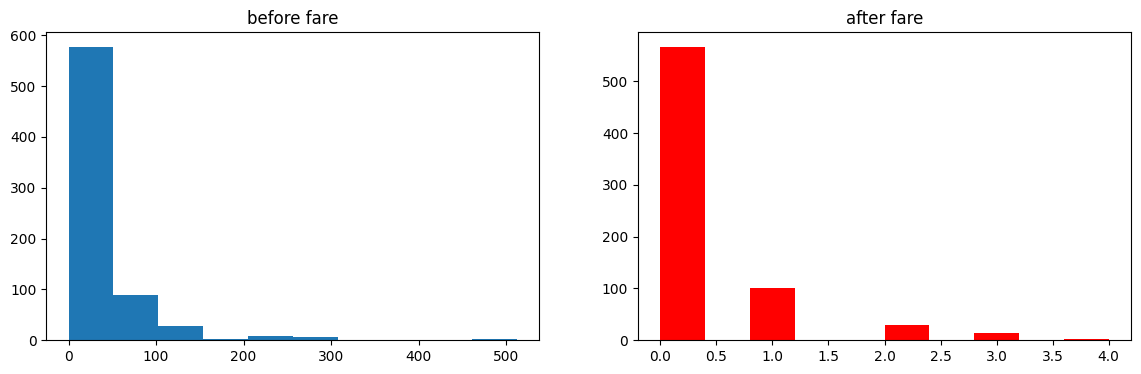

In [129]:
bin_discretizer(5,'ordinal','kmeans')